In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from   MRPy import MRPy

### Apresentação dos registros de dados adquiridos

### Cáculo da fraquencia natural e o respectivo periodo e o amortecimento:

 fs = 212.8Hz
 Td = 110.2s

 NX = 3
 N  = 23446
 M  = 11724



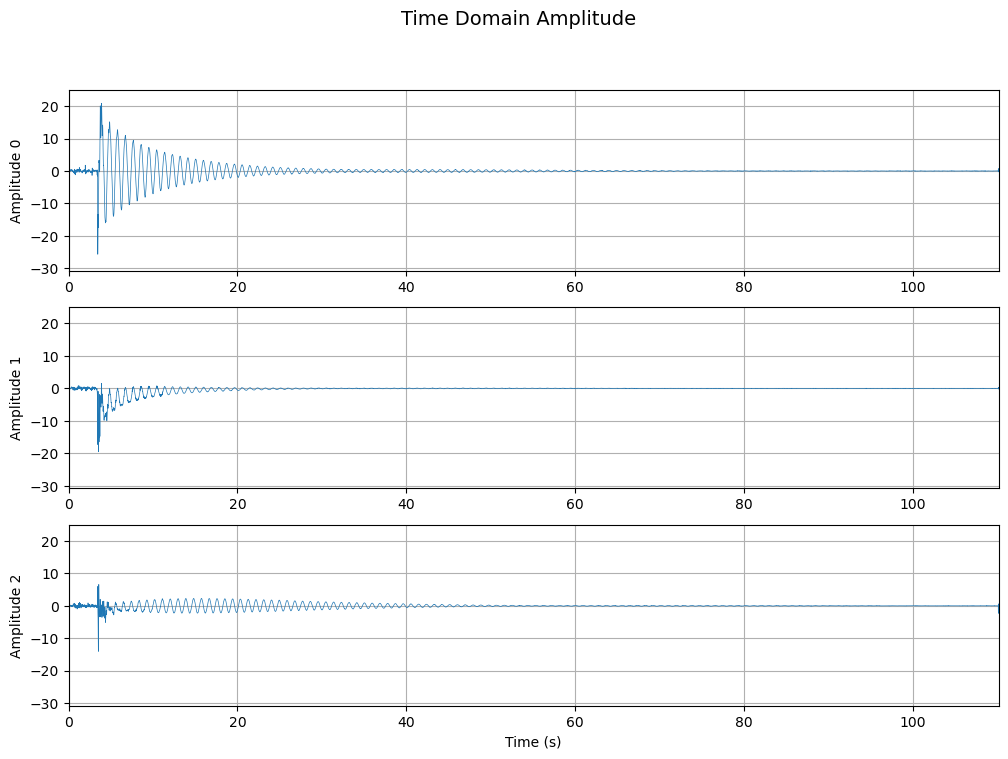

In [12]:
data = MRPy.from_file('data/leitura', form='invh')

data.printAttrib()
data.plot_time(fig=1);

 fs = 212.8Hz
 Td = 110.2s

 NX = 3
 N  = 23446
 M  = 11724



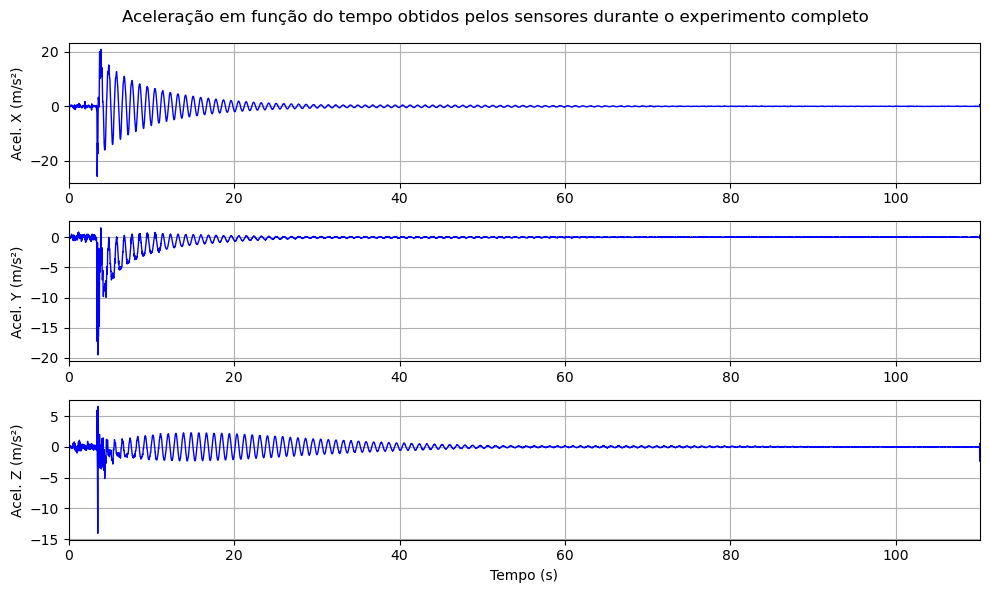

In [13]:
import matplotlib.pyplot as plt

data.printAttrib()

# Cria a figura e define os nomes que você quer usar

plt.figure(1, figsize=(10, 6), clear=True)

# Adição do título geral para os três subgráficos
plt.suptitle('Aceleração em função do tempo obtidos pelos sensores durante o experimento completo')

nomes_eixos = ['Acel. X (m/s²)', 'Acel. Y (m/s²)', 'Acel. Z (m/s²)']
t = data.t_axis()

for i, acc in enumerate(data):
    plt.subplot(3, 1, i+1)
    plt.plot(t, acc, color='blue', linewidth=1)
    
    # Aplica o nome correspondente da nossa lista
    plt.ylabel(nomes_eixos[i])
    plt.grid(True)
    # Limita o eixo X para os 110 segundos do seu ensaio
    plt.xlim(0, data.Td)

plt.xlabel('Tempo (s)')
plt.tight_layout()

 fs = 212.8Hz
 Td = 20.0s

 NX = 3
 N  = 4256
 M  = 2129



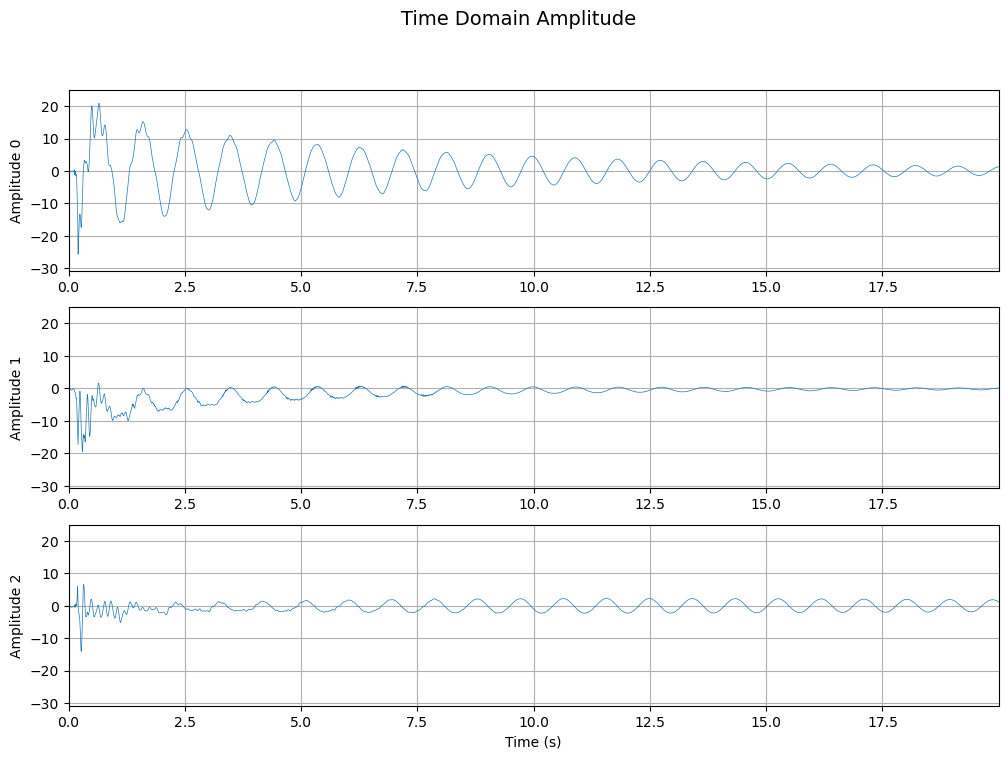

In [14]:
free = data.extract((3.25, 23.25), by='time')

free.printAttrib()
free.plot_time(fig=2);

 fs = 212.8Hz
 Td = 20.0s

 NX = 3
 N  = 4256
 M  = 2129



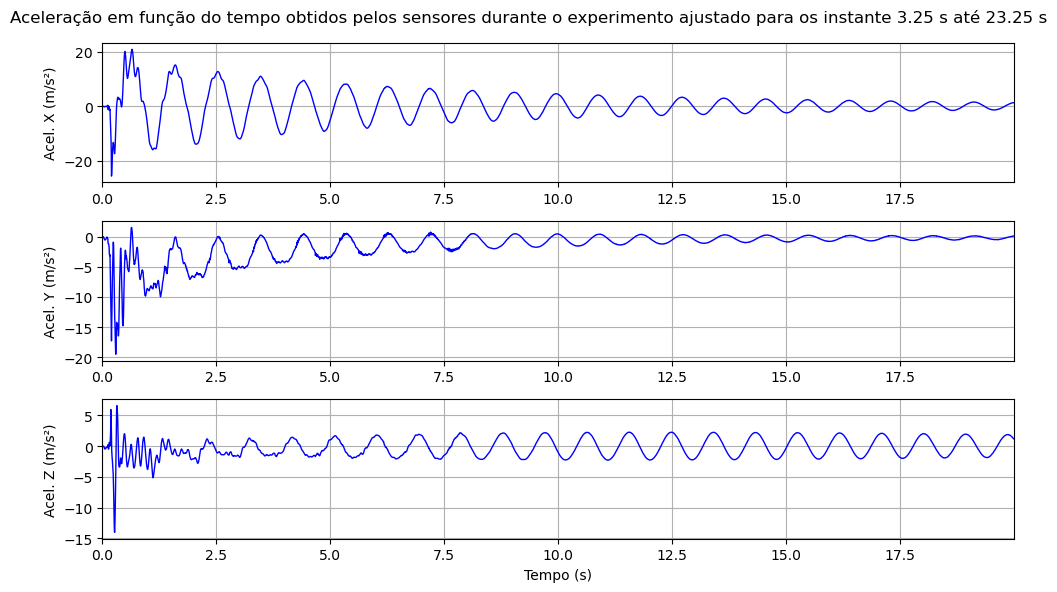

In [15]:
free = data.extract((3.25, 23.25), by='time')

free.printAttrib()

# Cria a figura 2 para o trecho recortado
plt.figure(2, figsize=(10, 6), clear=True)

# Adição do título geral para os três subgráficos
plt.suptitle('Aceleração em função do tempo obtidos pelos sensores durante o experimento ajustado para os instante 3.25 s até 23.25 s')

nomes_eixos = ['Acel. X (m/s²)', 'Acel. Y (m/s²)', 'Acel. Z (m/s²)']
t_free = free.t_axis()

for i, acc in enumerate(free):
    plt.subplot(3, 1, i+1)
    plt.plot(t_free, acc, color='blue', linewidth=1)
    
    # Aplica o nome correspondente da nossa lista
    plt.ylabel(nomes_eixos[i])
    plt.grid(True)
    
    # Limita o eixo X exatamente para o tamanho do trecho recortado
    plt.xlim(t_free[0], t_free[-1]) 

plt.xlabel('Tempo (s)')
plt.tight_layout()

Amplitude:     3.41m/s2
Frequency:     1.09Hz  
Damping ratio: 0.66%   
Phase:         -2.76rad 


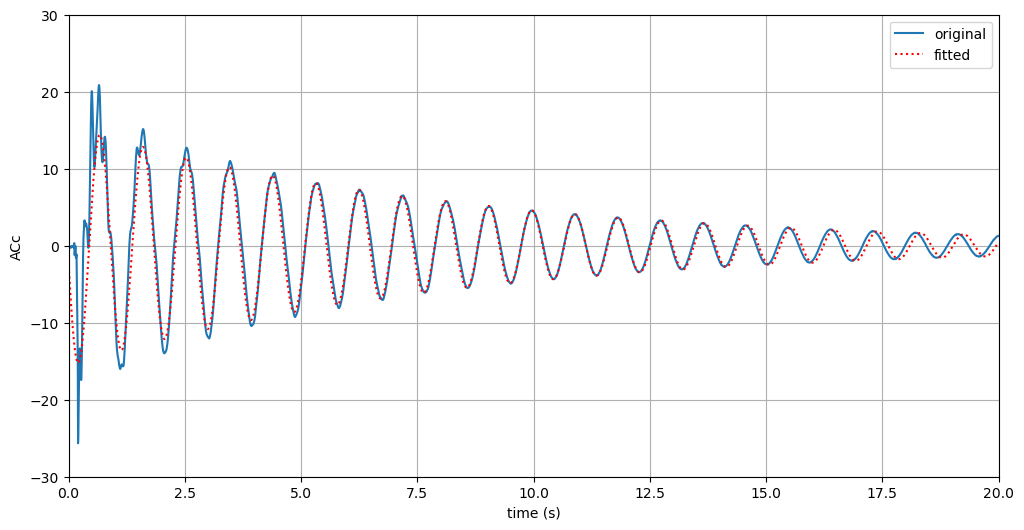

In [16]:
afit, par = free.fit_decay()
t         = free.t_axis()               # prepare time axis for plotting

plt.figure(4, figsize=(12, 6), clear=True)
plt.plot(t, free[0])
plt.plot(t, afit[0], 'r:')
plt.legend(('original','fitted'))

plt.xlim( 0, 20);  plt.xlabel('time (s)') 
plt.ylim(-30, 30);  plt.ylabel('ACc') 

plt.grid(True) 

print('Amplitude:     {0:4.2f}m/s2'.format(par[2,0]))
print('Frequency:     {0:4.2f}Hz  '.format(par[2,1]))
print('Damping ratio: {0:4.2f}%   '.format(par[2,2]*100))
print('Phase:         {0:4.2f}rad '.format(par[2,3]))

Amplitude:     3.41m/s2
Frequency:     1.09Hz  
Damping ratio: 0.66%   
Phase:         -2.76rad 


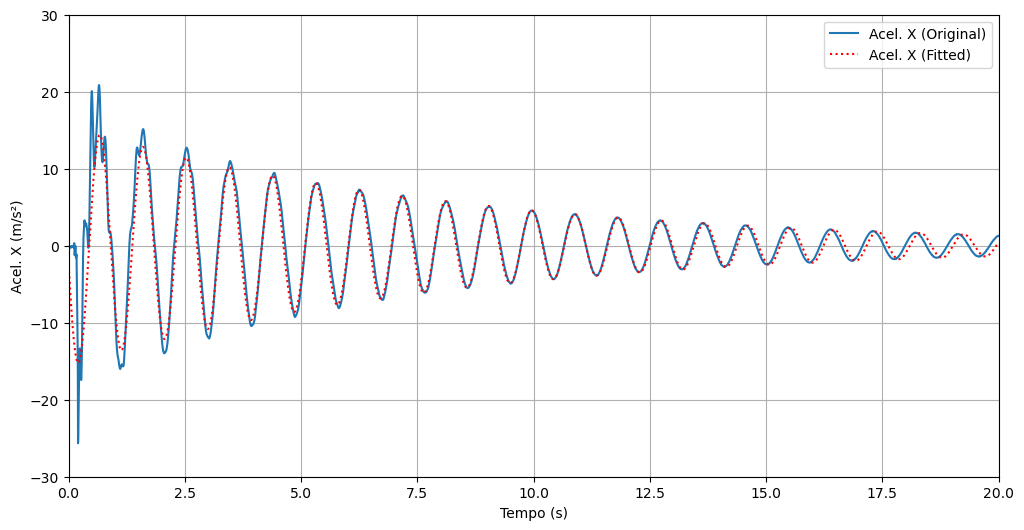

In [17]:
# (Mantenha as suas linhas originais de cálculo aqui em cima)
# afit, par = free.fit_decay()
# t         = free.t_axis() 

plt.figure(4, figsize=(12, 6), clear=True)
plt.plot(t, free[0])
plt.plot(t, afit[0], 'r:')

# 1. Ajuste da legenda para identificar claramente o Eixo X
plt.legend(('Acel. X (Original)', 'Acel. X (Fitted)'))

# 2. Ajuste do eixo X (Tempo)
plt.xlim(0, 20)
plt.xlabel('Tempo (s)') 

# 3. Ajuste do eixo Y (Aceleração com a unidade correta)
plt.ylim(-30, 30)
plt.ylabel('Acel. X (m/s²)') 

plt.grid(True) 

print('Amplitude:     {0:4.2f}m/s2'.format(par[2,0]))
print('Frequency:     {0:4.2f}Hz  '.format(par[2,1]))
print('Damping ratio: {0:4.2f}%   '.format(par[2,2]*100))
print('Phase:         {0:4.2f}rad '.format(par[2,3]))

Deslocamento físico máximo estimado da ponta da vara: 48.66 cm


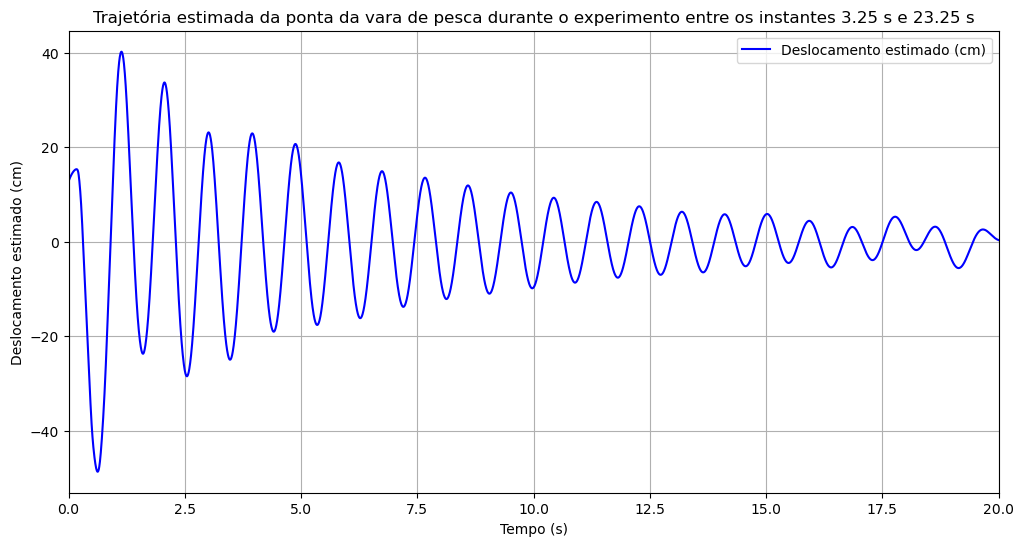

In [18]:
from scipy.signal import butter, filtfilt
from scipy.integrate import cumulative_trapezoid

# Pegando os dados de tempo, frequência e a onda de aceleração pura (Eixo X)
acc = free[0] - np.mean(free[0])
t = free.t_axis()
fs = free.fs  

# 1. Criação do Filtro Passa-Alta (Corte em 0.3 Hz)
# Isso mata o drift do celular, mas preserva a oscilação da vara (> 1 Hz)
b, a = butter(4, 0.3, btype='highpass', fs=fs)

# Filtramos a aceleração bruta
acc_filt = filtfilt(b, a, acc)

# 2. Primeira Integral: Aceleração -> Velocidade
vel = cumulative_trapezoid(acc_filt, t, initial=0)
vel_filt = filtfilt(b, a, vel)  # Filtra novamente a velocidade

# 3. Segunda Integral: Velocidade -> Deslocamento
disp = cumulative_trapezoid(vel_filt, t, initial=0)
disp_filt = filtfilt(b, a, disp) # Filtra novamente o deslocamento

# 4. Conversão final de Metros para Centímetros
disp_cm = disp_filt * 100

print(f"Deslocamento físico máximo estimado da ponta da vara: {np.max(np.abs(disp_cm)):.2f} cm")

# 5. Gráfico Final para o Relatório
plt.figure(5, figsize=(12, 6), clear=True)
plt.plot(t, disp_cm, color='blue', linewidth=1.5, label='Deslocamento estimado (cm)')

plt.xlim(0, 20)  
plt.xlabel('Tempo (s)')
plt.ylabel('Deslocamento estimado (cm)')
plt.title('Trajetória estimada da ponta da vara de pesca durante o experimento entre os instantes 3.25 s e 23.25 s')
plt.grid(True)
plt.legend()